In [1]:
# @title 1. Установка необходимых библиотек
!pip install pymorphy3 spacy
!python -m spacy download ru_core_news_sm

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import random
import spacy
import pymorphy3
from spacy import displacy

# Настройка графиков
%matplotlib inline
plt.rcParams['figure.figsize'] = [12, 5]
plt.rcParams['figure.dpi'] = 100

print("Библиотеки установлены!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 690.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 19.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 91.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('ru_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Библиотеки установлены!


In [2]:
# @title 2. Загрузка модели и текста
from google.colab import files

# Загружаем модели
nlp = spacy.load("ru_core_news_sm")
morph = pymorphy3.MorphAnalyzer()

print("Загрузите файл с русским романом:")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

# Берем фрагмент 30-100k символов
full_text = uploaded[file_name].decode('utf-8')
text = full_text[:80000]  # 80k символов

print(f"\nРазмер фрагмента: {len(text)} символов")
print(f"\nНачало текста:\n{'-'*50}")
print(text[:500])

Загрузите файл с русским романом:


Saving deadsouls.txt to deadsouls.txt

Размер фрагмента: 80000 символов

Начало текста:
--------------------------------------------------
Михаил Булгаков. Мертвые души


----------------------------------------------------------------------------
     Собрание сочинений в десяти томах. Том 6. М., "Голос", 1999.
     OCR Бычков М.Н.
----------------------------------------------------------------------------

               Комедия по поэме Н. В. Гоголя в четырех актах
                       (двенадцать картин с прологом)

ДЕЙСТВУЮТ:


     Первый в спектакле.
     Чичиков Павел Иванович.
     Секретарь опекунского 


In [3]:
# @title 3. Функции для токенов, стеммов, лемм
def get_tokens(text):
    """Простая токенизация"""
    words = re.findall(r'[а-яА-ЯёЁ]+', text)
    return [w.lower().replace('ё', 'е') for w in words]

def get_stems(text):
    """Стемминг (обрезка окончаний) - упрощенный вариант"""
    words = get_tokens(text)
    stems = []
    for word in words:
        # Простейший стеммер: убираем самые частые окончания
        if len(word) > 4:
            if word.endswith(('ать', 'ять', 'еть')):
                stem = word[:-3]
            elif word.endswith(('ой', 'ый', 'ий', 'ая', 'яя')):
                stem = word[:-2]
            elif word.endswith(('а', 'я', 'о', 'е', 'у', 'ю', 'и')):
                stem = word[:-1]
            else:
                stem = word
        else:
            stem = word
        stems.append(stem)
    return stems

def get_lemmas(text):
    """Лемматизация через pymorphy3"""
    words = get_tokens(text)
    lemmas = []
    for word in words[:10000]:  # Ограничим для скорости
        try:
            lemma = morph.parse(word)[0].normal_form
            lemmas.append(lemma)
        except:
            lemmas.append(word)
    return lemmas

def get_spacy_lemmas(text):
    """Лемматизация через spaCy"""
    doc = nlp(text[:50000])  # Ограничиваем
    return [token.lemma_.lower().replace('ё', 'е') for token in doc if token.is_alpha]

Функции готовы!



МЕТОД: Токены
Токенов: 10356
Типов: 3235
TTR: 0.3124

Топ-20 слов:
 1. чичиков           259
 2. не                250
 3. и                 205
 4. в                 198
 5. я                 198
 6. что               169
 7. как               125
 8. а                 116
 9. да                113
10. ноздрев           105
11. на                 96
12. вы                 83
13. с                  78
14. то                 66
15. ну                 66
16. так                65
17. ты                 65
18. за                 61
19. по                 60
20. мне                60

МЕТОД: Стеммы
Токенов: 10356
Типов: 2933
TTR: 0.2832

Топ-20 слов:
 1. чичиков           278
 2. не                250
 3. и                 205
 4. в                 198
 5. я                 198
 6. что               169
 7. как               150
 8. а                 116
 9. да                113
10. ноздрев           110
11. на                 96
12. так                88
13. вы                 83
14. с 

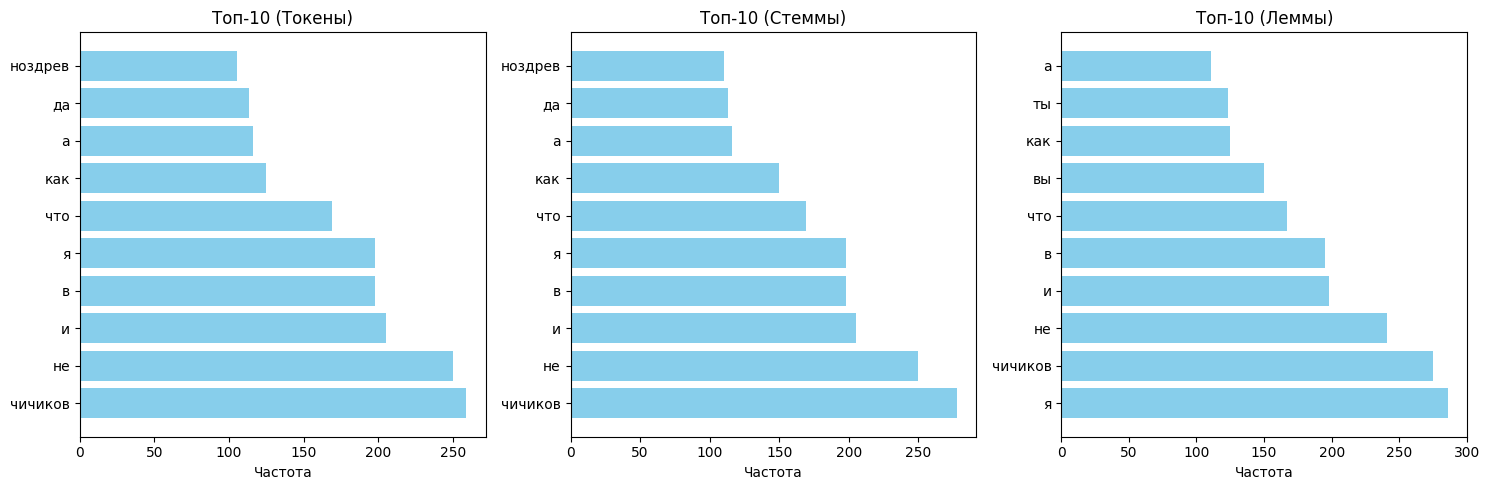

In [4]:
# @title 4. Сравнение топ-20 для токенов, стеммов, лемм
methods = {
    'Токены': get_tokens(text),
    'Стеммы': get_stems(text),
    'Леммы': get_lemmas(text)
}

results = {}
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, (method_name, words) in enumerate(methods.items()):
    if not words:
        continue

    cnt = Counter(words)
    N_tokens = len(words)
    V_types = len(cnt)
    top20 = cnt.most_common(20)

    results[method_name] = {
        'cnt': cnt,
        'N_tokens': N_tokens,
        'V_types': V_types,
        'top20': top20
    }

    print(f"МЕТОД: {method_name}")
    print(f"Токенов: {N_tokens}")
    print(f"Типов: {V_types}")
    print(f"TTR: {V_types/N_tokens:.4f}")
    print(f"\nТоп-20 слов:")
    for i, (word, count) in enumerate(top20, 1):
        print(f"{i:2d}. {word:15s} {count:5d}")

    # Визуализация топ-20
    words_top = [w for w, _ in top20[:10]]
    counts_top = [c for _, c in top20[:10]]

    axes[idx].barh(range(len(words_top)), counts_top, color='skyblue')
    axes[idx].set_yticks(range(len(words_top)))
    axes[idx].set_yticklabels(words_top)
    axes[idx].set_title(f'Топ-10 ({method_name})')
    axes[idx].set_xlabel('Частота')

plt.tight_layout()
plt.show()

АНАЛИЗ ДЛИННОГО ХВОСТА (ЧАСТОТА <= 3)

Токены:
  Типов с частотой ≤3: 2817 (87.1% словаря)
  Токенов с частотой ≤3: 3603 (34.8% текста)

Стеммы:
  Типов с частотой ≤3: 2495 (85.1% словаря)
  Токенов с частотой ≤3: 3267 (31.5% текста)

Леммы:
  Типов с частотой ≤3: 1751 (80.4% словаря)
  Токенов с частотой ≤3: 2406 (24.1% текста)


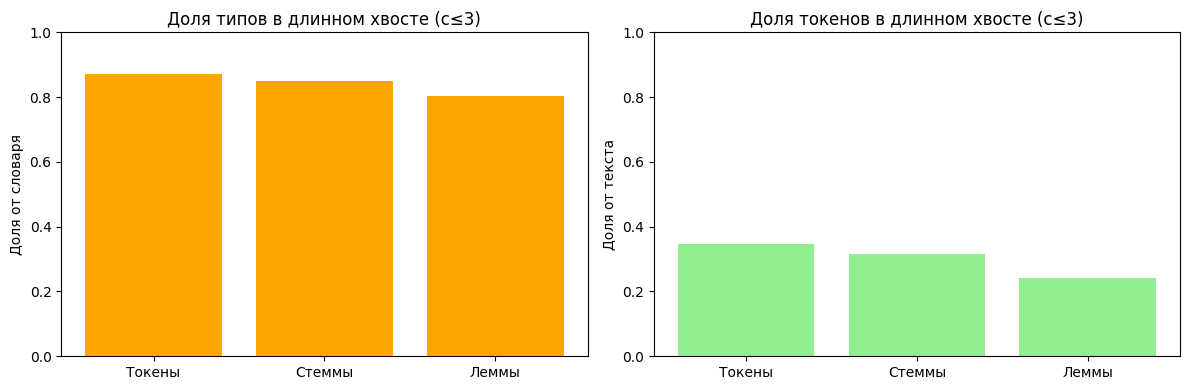

In [17]:
# @title 5. Доля длинного хвоста (c <= 3) для разных методов
print("АНАЛИЗ ДЛИННОГО ХВОСТА (ЧАСТОТА <= 3)")

tail_data = []

for method_name, data in results.items():
    cnt = data['cnt']
    V_types = data['V_types']
    N_tokens = data['N_tokens']

    # Слова с частотой <= 3
    tail_words = [w for w, c in cnt.items() if c <= 3]
    tail_types = len(tail_words)
    tail_tokens = sum(cnt[w] for w in tail_words)

    tail_data.append({
        'Метод': method_name,
        'Типов в хвосте': tail_types,
        '% типов': f"{tail_types/V_types:.1%}",
        'Токенов в хвосте': tail_tokens,
        '% токенов': f"{tail_tokens/N_tokens:.1%}"
    })

    print(f"\n{method_name}:")
    print(f"  Типов с частотой ≤3: {tail_types} ({tail_types/V_types:.1%} словаря)")
    print(f"  Токенов с частотой ≤3: {tail_tokens} ({tail_tokens/N_tokens:.1%} текста)")

# Визуализация
df_tail = pd.DataFrame(tail_data)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Доля типов в хвосте
types_pct = [float(d['% типов'].strip('%'))/100 for d in tail_data]
ax1.bar([d['Метод'] for d in tail_data], types_pct, color='orange')
ax1.set_title('Доля типов в длинном хвосте (c≤3)')
ax1.set_ylabel('Доля от словаря')
ax1.set_ylim(0, 1)

# Доля токенов в хвосте
tokens_pct = [float(d['% токенов'].strip('%'))/100 for d in tail_data]
ax2.bar([d['Метод'] for d in tail_data], tokens_pct, color='lightgreen')
ax2.set_title('Доля токенов в длинном хвосте (c≤3)')
ax2.set_ylabel('Доля от текста')
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [18]:
# @title 6. Выбор 5 предложений для детального анализа
def get_sentences(text, n=5):
    """Разбивает текст на предложения и выбирает случайные"""
    # Простое разбиение по знакам препинания
    sentences = re.split(r'[.!?]+', text)
    sentences = [s.strip() for s in sentences if len(s.strip().split()) > 3]
    return random.sample(sentences, min(n, len(sentences)))

selected_sentences = get_sentences(text, 5)

print("ВЫБРАННЫЕ ПРЕДЛОЖЕНИЯ ДЛЯ АНАЛИЗА:")
for i, sent in enumerate(selected_sentences, 1):
    print(f"\n{i}. {sent}")

ВЫБРАННЫЕ ПРЕДЛОЖЕНИЯ ДЛЯ АНАЛИЗА:

1. Счел  долгом  лично
представиться вашему превосходительству

2. Уж как вы ни упирайтесь, а мы вас женим, женим, женим

3. Нужно пропустить два  поворота
и поворотить на третий

4. Нет, будто и Михеева  продали

5. Да десятков до семи наберется


In [19]:
# @title 7. POS/DEP/NER от spaCy для выбранных предложений
print("SPACY АНАЛИЗ")

for i, sent in enumerate(selected_sentences, 1):
    print(f"\n--- ПРЕДЛОЖЕНИЕ {i} ---")
    print(f"Текст: {sent}")

    doc = nlp(sent)

    # Создаем таблицу с анализом
    data = []
    for token in doc:
        data.append({
            'Токен': token.text,
            'POS': token.pos_,
            'Tag': token.tag_,
            'DEP': token.dep_,
            'Лемма': token.lemma_,
            'NER': token.ent_type_ if token.ent_type_ else 'O'
        })

    df = pd.DataFrame(data)
    display(df)

    # Визуализация зависимостей
    print("\nСхема зависимостей:")
    displacy.render(doc, style='dep', jupyter=True, options={'compact': True, 'distance': 90})

SPACY АНАЛИЗ

--- ПРЕДЛОЖЕНИЕ 1 ---
Текст: Счел  долгом  лично
представиться вашему превосходительству


,Токен,POS,Tag,DEP,Лемма,NER
0,Счел,PROPN,PROPN,ROOT,счел,PER
1,,SPACE,SPACE,dep,,O
2,долгом,NOUN,NOUN,xcomp,долг,O
3,,SPACE,SPACE,dep,,O
4,лично,ADV,ADV,advmod,лично,O
5,\r\n,SPACE,SPACE,dep,\r\n,O
6,представиться,VERB,VERB,xcomp,представиться,O
7,вашему,DET,DET,det,ваш,O
8,превосходительству,NOUN,NOUN,iobj,превосходительство,O



Схема зависимостей:



--- ПРЕДЛОЖЕНИЕ 2 ---
Текст: Уж как вы ни упирайтесь, а мы вас женим, женим, женим


,Токен,POS,Tag,DEP,Лемма,NER
0,Уж,PART,PART,advmod,уж,O
1,как,SCONJ,SCONJ,mark,как,O
2,вы,PRON,PRON,nsubj,вы,O
3,ни,PART,PART,advmod,ни,O
4,упирайтесь,VERB,VERB,ROOT,упираться,O
5,",",PUNCT,PUNCT,punct,",",O
6,а,CCONJ,CCONJ,cc,а,O
7,мы,PRON,PRON,nsubj,мы,O
8,вас,PRON,PRON,obj,вас,O
9,женим,ADJ,ADJ,conj,женим,O


...

,Токен,POS,Tag,DEP,Лемма,NER
0,Нет,PART,PART,parataxis,нет,O
1,",",PUNCT,PUNCT,punct,",",O
2,будто,SCONJ,SCONJ,mark,будто,O
3,и,PART,PART,advmod,и,O
4,Михеева,PROPN,PROPN,advcl,михеев,PER
5,,SPACE,SPACE,dep,,O
6,продали,VERB,VERB,ROOT,продать,O



Схема зависимостей:



--- ПРЕДЛОЖЕНИЕ 5 ---
Текст: Да десятков до семи наберется


,Токен,POS,Tag,DEP,Лемма,NER
0,Да,PART,PART,advmod,да,O
1,десятков,NOUN,NOUN,case,десяток,O
2,до,ADP,ADP,case,до,O
3,семи,NUM,NUM,nummod,семь,O
4,наберется,VERB,VERB,ROOT,наберется,O



Схема зависимостей:


In [9]:
# @title 8. Леммы от pymorphy3 для тех же предложений
print("PYMORPHY3 АНАЛИЗ")


for i, sent in enumerate(selected_sentences, 1):
    print(f"\n--- ПРЕДЛОЖЕНИЕ {i} ---")
    print(f"Текст: {sent}")

    words = re.findall(r'[а-яА-ЯёЁ]+', sent)
    data = []

    for word in words:
        try:
            parsed = morph.parse(word)[0]
            data.append({
                'Слово': word,
                'Лемма (pymorphy3)': parsed.normal_form,
                'POS': parsed.tag.POS,
                'Падеж': parsed.tag.case,
                'Число': parsed.tag.number,
                'Род': parsed.tag.gender
            })
        except:
            data.append({
                'Слово': word,
                'Лемма (pymorphy3)': word,
                'POS': 'UNKN',
                'Падеж': '-',
                'Число': '-',
                'Род': '-'
            })

    df = pd.DataFrame(data)
    display(df)

    # Сравнение лемм spaCy и pymorphy3
    print("\nСравнение лемм:")
    doc = nlp(sent)
    spacy_lemmas = [token.lemma_ for token in doc if token.is_alpha]

    for word, spacy_lem in zip(words, spacy_lemmas):
        pymorphy_lem = morph.parse(word)[0].normal_form
        print(f"{word:15s} | spaCy: {spacy_lem:15s} | pymorphy3: {pymorphy_lem:15s} | {'✓' if spacy_lem == pymorphy_lem else '✗'}")

PYMORPHY3 АНАЛИЗ

--- ПРЕДЛОЖЕНИЕ 1 ---
Текст: Помилуй, на что ж мне жеребец


,Слово,Лемма (pymorphy3),POS,Падеж,Число,Род
0,Помилуй,помиловать,VERB,None,sing,None
1,на,на,PREP,None,None,None
2,что,что,CONJ,None,None,None
3,ж,ж,PRCL,None,None,None
4,мне,я,NPRO,datv,sing,None
5,жеребец,жеребец,NOUN,nomn,sing,masc



Сравнение лемм:
Помилуй         | spaCy: помилуй         | pymorphy3: помиловать      | ✗
на              | spaCy: на              | pymorphy3: на              | ✓
что             | spaCy: что             | pymorphy3: что             | ✓
ж               | spaCy: ж               | pymorphy3: ж               | ✓
мне             | spaCy: мне             | pymorphy3: я               | ✗
жеребец         | spaCy: жеребец         | pymorphy3: жеребец         | ✓

--- ПРЕДЛОЖЕНИЕ 2 ---
Текст: Душой бы рад был, но не могу


,Слово,Лемма (pymorphy3),POS,Падеж,Число,Род
0,Душой,душа,NOUN,ablt,sing,femn
1,бы,бы,PRCL,None,None,None
2,рад,рад,ADJS,None,sing,masc
3,был,быть,VERB,None,sing,masc
4,но,но,CONJ,None,None,None
5,не,не,PRCL,None,None,None
6,могу,мочь,VERB,None,sing,None



Сравнение лемм:
Душой           | spaCy: душой           | pymorphy3: душа            | ✗
бы              | spaCy: бы              | pymorphy3: бы              | ✓
рад             | spaCy: рад             | pymorphy3: рад             | ✓
был             | spaCy: быть            | pymorphy3: быть            | ✓
но              | spaCy: но              | pymorphy3: но              | ✓
не              | spaCy: не              | pymorphy3: не              | ✓
могу            | spaCy: мочь            | pymorphy3: мочь            | ✓

--- ПРЕДЛОЖЕНИЕ 3 ---
Текст: Уж  точно  почтенная  и
верная


...


Сравнение лемм:
Уж              | spaCy: уж              | pymorphy3: уж              | ✓
точно           | spaCy: точно           | pymorphy3: точно           | ✓
почтенная       | spaCy: почесть         | pymorphy3: почтенный       | ✗
и               | spaCy: и               | pymorphy3: и               | ✓
верная          | spaCy: верный          | pymorphy3: верный          | ✓

--- ПРЕДЛОЖЕНИЕ 4 ---
Текст: Ты ее  только  перекрасишь  -  будет
чудо-бричка


,Слово,Лемма (pymorphy3),POS,Падеж,Число,Род
0,Ты,ты,NPRO,nomn,sing,None
1,ее,она,NPRO,accs,sing,femn
2,только,только,ADVB,None,None,None
3,перекрасишь,перекрасить,VERB,None,sing,None
4,будет,быть,VERB,None,sing,None
5,чудо,чудо,NOUN,nomn,sing,neut
6,бричка,бричка,NOUN,nomn,sing,femn



Сравнение лемм:
Ты              | spaCy: ты              | pymorphy3: ты              | ✓
ее              | spaCy: ее              | pymorphy3: она             | ✗
только          | spaCy: только          | pymorphy3: только          | ✓
перекрасишь     | spaCy: перекрасить     | pymorphy3: перекрасить     | ✓
будет           | spaCy: быть            | pymorphy3: быть            | ✓
чудо            | spaCy: чудо            | pymorphy3: чудо            | ✓
бричка          | spaCy: бричка          | pymorphy3: бричка          | ✓

--- ПРЕДЛОЖЕНИЕ 5 ---
Текст: )
     Коробочка (долго крестится)


,Слово,Лемма (pymorphy3),POS,Падеж,Число,Род
0,Коробочка,коробочка,NOUN,nomn,sing,femn
1,долго,долго,ADVB,None,None,None
2,крестится,креститься,VERB,None,sing,None



Сравнение лемм:
Коробочка       | spaCy: коробочка       | pymorphy3: коробочка       | ✓
долго           | spaCy: долго           | pymorphy3: долго           | ✓
крестится       | spaCy: крестится       | pymorphy3: креститься      | ✗


In [10]:
# @title 9. Список имен персонажей
print("ИМЕНА ПЕРСОНАЖЕЙ")

# Анализируем весь текст на имена
doc = nlp(text[:50000])

names = []
for ent in doc.ents:
    if ent.label_ == "PER" or ent.label_ == "PERSON":
        names.append(ent.text)

# Считаем частоту имен
name_counts = Counter(names)

print(f"Найдено уникальных имен: {len(name_counts)}")
print(f"\nТоп-20 самых частых персонажей:")

for i, (name, count) in enumerate(name_counts.most_common(20), 1):
    print(f"{i:2d}. {name:20s} {count:3d} упоминаний")

# Ищем варианты одного имени
print(f"\nВарианты имени 'Андрей':")
for name in name_counts:
    if 'Андрей' in name or 'Андре' in name:
        print(f"  {name}: {name_counts[name]}")

ИМЕНА ПЕРСОНАЖЕЙ
Найдено уникальных имен: 100

Топ-20 самых частых персонажей:
 1. Чичиков              186 упоминаний
 2. Ноздрев               74 упоминаний
 3. Манилов               42 упоминаний
 4. Собакевич             41 упоминаний
 5. Плюшкин               38 упоминаний
 6. Мижуев                20 упоминаний
 7. Павел Иванович         9 упоминаний
 8. Пауза                  8 упоминаний
 9. Чичикова               6 упоминаний
10. Селифан                5 упоминаний
11. Почтмейстер            4 упоминаний
12. Манилова               4 упоминаний
13. Половой                3 упоминаний
14. Иван Григорьевич       3 упоминаний
15. Полицеймейстер         3 упоминаний
16. Михаил Семенович       2 упоминаний
17. Секретарю              2 упоминаний
18. Слуга                  2 упоминаний
19. Собакевича             2 упоминаний
20. Манилову               2 упоминаний

Варианты имени 'Андрей':
  Почтмейстер Иван Андреевич: 1
  Иван Андреевич: 1


In [11]:
# @title 10. НОВЫЙ ИНТЕНТ 1: Поиск предложений с приветствиями
def find_greetings(text):
    """Находит предложения, где здороваются"""
    # Паттерны приветствий
    greeting_patterns = [
        r'[Зз]дравствуй[те]*',
        r'[Пп]ривет',
        r'[Дд]обрый (день|вечер|утро)',
        r'[Сс]алют',
        r'[Хх]елло',
        r'[Рр]ад [вас]* видеть',
        r'[Пп]озвольте представиться',
        r'[Дд]расте',
        r'[Бб]онжур'
    ]

    # Разбиваем на предложения
    sentences = re.split(r'[.!?]+', text)
    sentences = [s.strip() for s in sentences if len(s.strip()) > 10]

    greeting_sentences = []

    for sent in sentences:
        for pattern in greeting_patterns:
            if re.search(pattern, sent, re.IGNORECASE):
                greeting_sentences.append(sent)
                break

    print(f"\n{'='*60}")
    print("ПОИСК ПРИВЕТСТВИЙ")
    print('='*60)
    print(f"Найдено предложений с приветствиями: {len(greeting_sentences)}")

    if greeting_sentences:
        print(f"\nПримеры (первые 10):")
        for i, sent in enumerate(greeting_sentences[:10], 1):
            clean_sent = re.sub(r'\s+', ' ', sent).strip()
            if len(clean_sent) > 100:
                clean_sent = clean_sent[:100] + "..."
            print(f"{i:2d}. {clean_sent}")

    return greeting_sentences

greetings = find_greetings(text)


ПОИСК ПРИВЕТСТВИЙ
Найдено предложений с приветствиями: 6

Примеры (первые 10):
 1. Здравствуй, полицеймейстер
 2. Приветливая и говорливая хозяйка
 3. Здравствуйте, Анна Григорьевна
 4. Здравствуйте, Софья Ивановна
 5. Сысой Пафнутьевич, здравствуйте
 6. Здравствуйте, Антипатор Захарьевич


In [12]:
# @title 11. НОВЫЙ ИНТЕНТ 2: Поиск диалогов и прямой речи
def find_dialogues(text):
    """Находит предложения с прямой речью"""
    # Паттерны для диалогов
    dialogue_patterns = [
        r'«[^»]+»',           # Кавычки «...»
        r'"[^"]+"',           # Кавычки "..."
        r'\-[^\-]+',          # Диалоги с тире
        r'сказал[а]*:? [«"]', # Глаголы говорения
        r'ответил[а]*:? [«"]',
        r'промолвил[а]*:? [«"]',
        r'крикнул[а]*:? [«"]',
        r'спросил[а]*:? [«"]'
    ]

    dialogues = []

    for pattern in dialogue_patterns:
        matches = re.findall(pattern, text)
        dialogues.extend(matches)

    # Очищаем и убираем дубликаты
    dialogues = list(set([d.strip() for d in dialogues if len(d.strip()) > 5]))

    print("ПОИСК ДИАЛОГОВ")
    print(f"Найдено фрагментов с прямой речью: {len(dialogues)}")

    if dialogues:
        print(f"\nПримеры диалогов (первые 10):")
        for i, d in enumerate(dialogues[:10], 1):
            clean_d = re.sub(r'\s+', ' ', d).strip()
            if len(clean_d) > 80:
                clean_d = clean_d[:80] + "..."
            print(f"{i:2d}. {clean_d}")

    return dialogues

dialogues = find_dialogues(text)


ПОИСК ДИАЛОГОВ
Найдено фрагментов с прямой речью: 207

Примеры диалогов (первые 10):
 1. - подумал Губернатор. "Дурак этот губернатор",
 2. -исправник. Капитан Копейкин. Мижуев, зять. Действие происходит в 30
 3. -нибудь, то есть критическое предосуждение о вас! Но позвольте доложить, не буде...
 4. - Чубарый
 5. - мокрые и грязные, вносят шкатулку. Чичиков. Извините, матушка, что побеспокоил...
 6. "его не собьешь, не податлив"
 7. - и в руку целует. А я ему такой же дядюшка, как он мне дедушка. И как начнет со...
 8. - он вышьет вам кошелек, он вас за копейку зарежет. Он да еще вице
 9. - мертвые души. Почтмейстер. Как человек, судырь ты мой, он светского лоску... П...
10. -то заболел. Полощет горло молоком с фигой. Придется расспросить людей. (В дверь...


In [20]:
# @title 12. НОВОЕ ПРАВИЛО (Matcher): Поиск обращений
from spacy.matcher import Matcher

matcher = Matcher(nlp.vocab)

# Паттерны для обращений
patterns = [
    # Обращение по имени + глагол
    [{"POS": "PROPN"}, {"POS": "VERB"}],
    # Господин/Госпожа + фамилия
    [{"LOWER": {"IN": ["господин", "госпожа", "товарищ", "князь", "граф"]}},
     {"POS": "PROPN"}],
    # Дорогой/Уважаемый + имя
    [{"LOWER": {"IN": ["дорогой", "уважаемый", "милый", "любезный"]}},
     {"POS": "PROPN", "OP": "?"}],
    # Имя + обращения типа "батюшка", "матушка"
    [{"POS": "PROPN"}, {"LOWER": {"IN": ["батюшка", "матушка", "сударь", "сударыня"]}}]
]

for i, pattern in enumerate(patterns):
    matcher.add(f"ADDRESS_{i}", [pattern])

# Применяем к тексту
doc = nlp(text[:50000])
matches = matcher(doc)

print("ПРАВИЛО 1 (Matcher): Поиск обращений")
print(f"Найдено обращений: {len(matches)}")

print(f"\nПримеры обращений:")
unique_addresses = set()
for match_id, start, end in matches[:30]:
    span = doc[start:end]
    unique_addresses.add(span.text)

for i, addr in enumerate(list(unique_addresses)[:15], 1):
    print(f"{i:2d}. {addr}")

ПРАВИЛО 1 (Matcher): Поиск обращений
Найдено обращений: 28

Примеры обращений:
 1. Селифана появляется
 2. Мижуев уходит
 3. Ноздрев захохотал
 4. Манилов обнимаются
 5. Чичиков исчезает
 6. Манилов уронил
 7. Чичиков садится
 8. Чичиков берет
 9. Пари держу
10. Манилов раскланиваются
11. Мижуев удаляется
12. Чичиков кланяются
13. Заря угасает
14. господин Ноздрев
15. Манилов оглядывается


In [14]:
# @title 13. НОВОЕ ПРАВИЛО (Regex): Поиск восклицательных конструкций
def find_exclamations_with_emotion(text):
    """Находит восклицания с эмоциональной окраской"""
    # Паттерны эмоциональных восклицаний
    emotion_patterns = [
        (r'[А-Я][^.!?]*![^.!?]*', 'восклицание'),
        (r'(ах|ох|ух|эх|ой|ай)[\s,!]', 'междометие'),
        (r'(как|какой|сколько)[\s]+[^.!?]+!', 'восхищение'),
        (r'(боже|господи|черт)[\s,!]', 'эмоциональное обращение'),
        (r'(прекрасно|чудесно|ужасно|замечательно)[\s,!]', 'эмоциональная оценка')
    ]

    sample_text = text[:100000]
    results = {}

    print("ПРАВИЛО 2 (Regex): Поиск эмоциональных восклицаний")

    for pattern, name in emotion_patterns:
        matches = re.findall(pattern, sample_text, re.IGNORECASE)
        results[name] = len(matches)
        print(f"\n{name}: {len(matches)} вхождений")

        if matches:
            print(f"  Примеры: {matches[:5]}")

    return results

emotions = find_exclamations_with_emotion(text)


ПРАВИЛО 2 (Regex): Поиск эмоциональных восклицаний

восклицание: 192 вхождений
  Примеры: ['и увернулся из-под уголовного суда! Но уже ни  капитала,  ни\r\nразных  заграничных  вещиц,  ничего  не  осталось  ему', 'Вот  в  каком\r\nположении очутился герой наш!', 'В нем не потухла непостижимая страсть к приобретению!\r\n     ', 'С главы ее мертвой сняв черную шаль!\r\nОтер  я  безмолвно кровавую сталь', 'Хорошо! Дайте бумаги']

междометие: 211 вхождений
  Примеры: ['ах', 'ой', 'ой', 'ах', 'ой']

восхищение: 14 вхождений
  Примеры: ['как', 'как', 'как', 'как', 'как']

эмоциональное обращение: 15 вхождений
  Примеры: ['черт', 'черт', 'черт', 'Господи', 'черт']

эмоциональная оценка: 0 вхождений


СРАВНИТЕЛЬНАЯ ТАБЛИЦА ПО МЕТОДАМ


,Метод,Токенов,Типов,TTR,Топ-1,Частота топ-1,Уникальность
0,Токены,10356,3235,0.3124,чичиков,259,31.24%
1,Стеммы,10356,2933,0.2832,чичиков,278,28.32%
2,Леммы,10000,2178,0.2178,я,286,21.78%


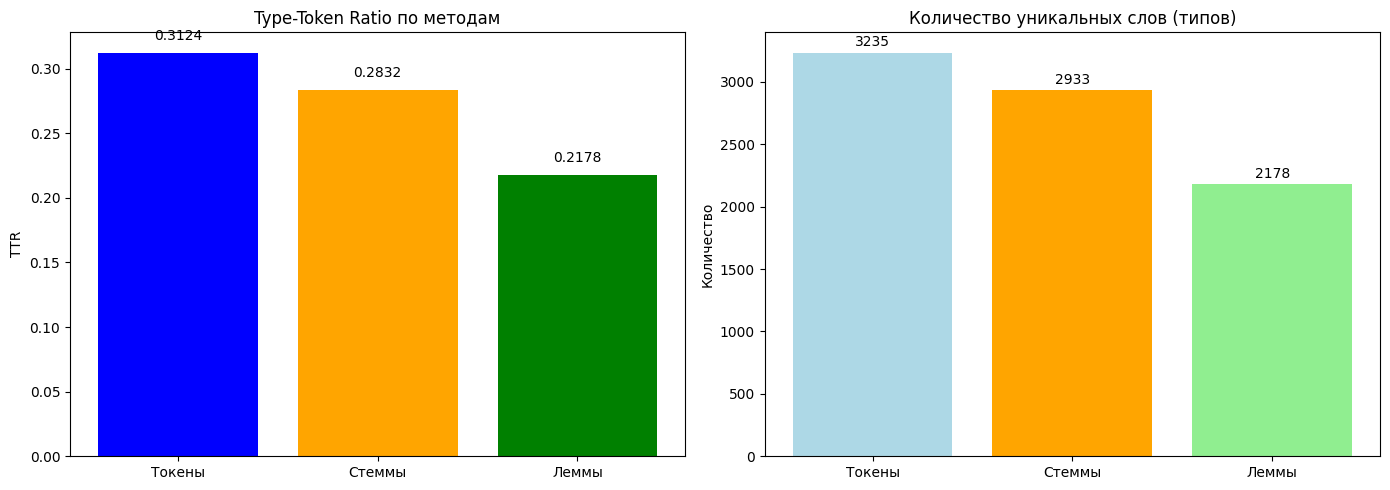

In [16]:
# @title 14. Итоговая таблица сравнения

print("СРАВНИТЕЛЬНАЯ ТАБЛИЦА ПО МЕТОДАМ")

comparison_data = []
for method_name, data in results.items():
    comparison_data.append({
        'Метод': method_name,
        'Токенов': data['N_tokens'],
        'Типов': data['V_types'],
        'TTR': f"{data['V_types']/data['N_tokens']:.4f}",
        'Топ-1': data['top20'][0][0],
        'Частота топ-1': data['top20'][0][1],
        'Уникальность': f"{data['V_types']/data['N_tokens']*100:.2f}%"
    })

df_comparison = pd.DataFrame(comparison_data)
display(df_comparison)

# Визуализация сравнения
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# TTR сравнение
ttr_values = [float(d['TTR']) for d in comparison_data]
axes[0].bar([d['Метод'] for d in comparison_data], ttr_values,
            color=['blue', 'orange', 'green'])
axes[0].set_title('Type-Token Ratio по методам')
axes[0].set_ylabel('TTR')
for i, v in enumerate(ttr_values):
    axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center')

# Количество типов
types_values = [d['Типов'] for d in comparison_data]
axes[1].bar([d['Метод'] for d in comparison_data], types_values,
            color=['lightblue', 'orange', 'lightgreen'])
axes[1].set_title('Количество уникальных слов (типов)')
axes[1].set_ylabel('Количество')
for i, v in enumerate(types_values):
    axes[1].text(i, v + 50, f'{v}', ha='center')

plt.tight_layout()
plt.show()